# 03 — Detecção de valores atípicos

Método: resíduo em log do custo por internação vs. esperado (mesmo subgrupo e UF, ajustado ao nível nacional do
mês), padronizado por um modelo de variância `a/n + b` (ruído amostral + sobredispersão, como em funnel plots).
Detalhes em `docs/methodology.md`.

A base sintética tem **anomalias injetadas com gabarito** (`data/raw/*_gabarito.csv`), o que permite medir
precisão e recall do método — algo raramente possível com dados reais.

> ⚠️ Base sintética — resultados ilustrativos.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from hcb.config import load_settings
from hcb.analysis import indicators, statistics, outliers
from hcb.pipeline import FACT_FILE, run
from hcb.schema import REGION_ORDER

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.titlelocation": "left"})
REGION_COLORS = {"Norte": "#2a78d6", "Nordeste": "#eb6834", "Centro-Oeste": "#1baf7a",
                 "Sudeste": "#eda100", "Sul": "#e87ba4"}

settings = load_settings()
if not (settings.processed_dir / FACT_FILE).exists():
    run(settings)
fact = pd.read_csv(settings.processed_dir / FACT_FILE, dtype={"subgrupo_codigo": str, "grupo_codigo": str},
                   parse_dates=["data"])
fact["regiao"] = pd.Categorical(fact["regiao"], categories=REGION_ORDER, ordered=True)
print(f"{len(fact):,} linhas | {fact['competencia'].min()} a {fact['competencia'].max()}")


14,992 linhas | 2022-01 a 2024-12


In [2]:
o = settings.outliers
scored = outliers.detect_outliers(fact, o["z_threshold"], o["min_admissions"])
flagged = outliers.outlier_table(scored)
print(f"Células atípicas: {len(flagged)} de {scored['z_robusto'].notna().sum():,} avaliadas")
flagged.head(10)

Células atípicas: 55 de 14,992 avaliadas


,competencia,uf_sigla,regiao,subgrupo_codigo,subgrupo_nome,qtd_internacoes,valor_total,custo_por_internacao,custo_esperado,z_robusto,direcao_atipicidade,excesso_estimado
0,2024-03,SC,Sul,0303,Tratamentos clínicos (outras especialidades),13493,"78,682,942.32","5,831.39","1,305.78",89.94,acima do esperado,"61,064,011.04"
1,2024-05,ES,Sudeste,0407,"Cirurgia do aparelho digestivo, órgãos anexos ...",2246,"12,776,472.35","5,688.55","1,450.38",81.50,acima do esperado,"9,518,913.68"
2,2022-10,AL,Nordeste,0310,Parto e nascimento,2056,"5,380,475.05","2,616.96",683.67,75.76,acima do esperado,"3,974,859.40"
3,2024-06,SE,Nordeste,0408,Cirurgia do sistema osteomuscular,920,"9,909,843.70","10,771.57","2,094.65",75.60,acima do esperado,"7,982,768.60"
4,2024-07,DF,Centro-Oeste,0408,Cirurgia do sistema osteomuscular,1292,"15,459,068.78","11,965.22","2,626.20",74.51,acima do esperado,"12,066,014.83"
5,2024-09,PA,Norte,0409,Cirurgia do aparelho geniturinário,1742,"8,351,869.58","4,794.41","1,172.58",71.50,acima do esperado,"6,309,234.48"
6,2024-06,RS,Sul,0406,Cirurgia do aparelho circulatório,2008,"97,894,814.94","48,752.40","9,601.38",69.81,acima do esperado,"78,615,246.75"
7,2022-11,SP,Sudeste,0303,Tratamentos clínicos (outras especialidades),68351,"262,161,585.56","3,835.52","1,267.87",67.35,acima do esperado,"175,501,334.09"
8,2024-02,PI,Nordeste,0310,Parto e nascimento,2076,"5,147,199.53","2,479.38",757.86,67.09,acima do esperado,"3,573,874.01"
9,2022-10,SP,Sudeste,0406,Cirurgia do aparelho circulatório,6699,"271,316,343.47","40,501.02","9,813.75",66.83,acima do esperado,"205,574,031.99"


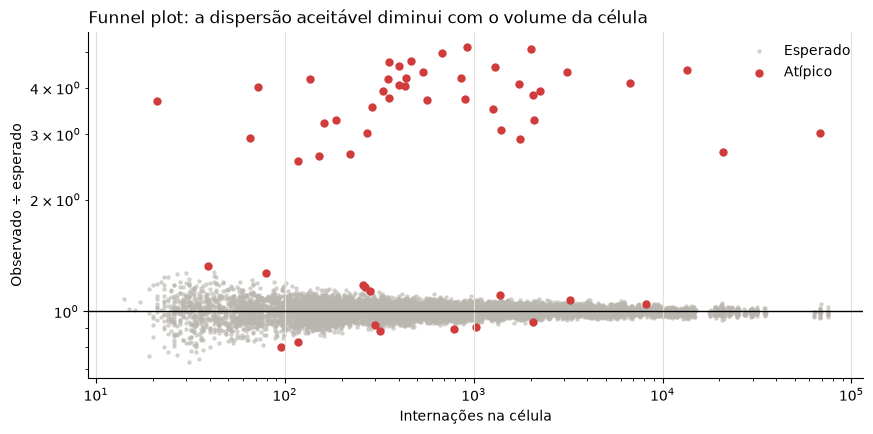

In [3]:
ratio = scored["custo_por_internacao"] / scored["custo_esperado"]
flag = scored["atipico"]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(scored.loc[~flag, "qtd_internacoes"], ratio[~flag], s=5, color="#b8b6ae", alpha=0.5, label="Esperado")
ax.scatter(scored.loc[flag, "qtd_internacoes"], ratio[flag], s=25, color="#d03b3b", label="Atípico")
ax.axhline(1, color="black", lw=1); ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Internações na célula"); ax.set_ylabel("Observado ÷ esperado"); ax.legend(frameon=False)
ax.set_title("Funnel plot: a dispersão aceitável diminui com o volume da célula")
plt.show()

## Validação contra o gabarito

In [4]:
gab_path = settings.raw_file.with_name(settings.raw_file.stem + "_gabarito.csv")
if settings.source_type == "synthetic" and gab_path.exists():
    keys = ["competencia", "uf_sigla", "subgrupo_codigo"]
    truth = pd.read_csv(gab_path, dtype=str).query("tipo == 'custo_inflado'")[keys]
    hits = truth.merge(flagged[keys], on=keys)
    precision, recall = len(hits) / len(flagged), len(hits) / len(truth)
    print(f"Anomalias injetadas: {len(truth)} | sinalizadas: {len(flagged)} | acertos: {len(hits)}")
    print(f"Precisão: {precision:.1%} | Recall: {recall:.1%}")
    for thr in [3.0, 3.5, 4.0, 5.0]:
        f = scored[scored["z_robusto"].abs() > thr][keys]
        h = truth.merge(f, on=keys)
        prec, rec = len(h) / max(len(f), 1), len(h) / len(truth)
        print(f"  limiar {thr}: sinalizadas={len(f):>4}  precisão={prec:.1%}  recall={rec:.1%}")

Anomalias injetadas: 40 | sinalizadas: 55 | acertos: 40
Precisão: 72.7% | Recall: 100.0%
  limiar 3.0: sinalizadas=  97  precisão=41.2%  recall=100.0%
  limiar 3.5: sinalizadas=  55  precisão=72.7%  recall=100.0%
  limiar 4.0: sinalizadas=  44  precisão=90.9%  recall=100.0%
  limiar 5.0: sinalizadas=  40  precisão=100.0%  recall=100.0%


**Leitura:** o limiar controla o equilíbrio entre falsos positivos (custo de auditoria) e falsos
negativos (risco não detectado). Na prática, calibre o limiar com a capacidade da equipe de auditoria e
valide uma amostra de casos sinalizados. Atipicidade **não** comprova erro, fraude ou ineficiência.